In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [69]:
np_comb = np.vectorize(math.comb)
np_fact = np.vectorize(math.factorial)

def bin(x, n, p):
    return np_comb(n, x) * (1-p)**(n-x) * p**x

def hypgeo(x, n, M, N):
    return (np_comb(M, x) * np_comb(N-M, n-x))/np_comb(N, n)

def poisson(x, mu):
    return np.exp(-mu) * mu**x / np_fact(x)

<BarContainer object of 10 artists>

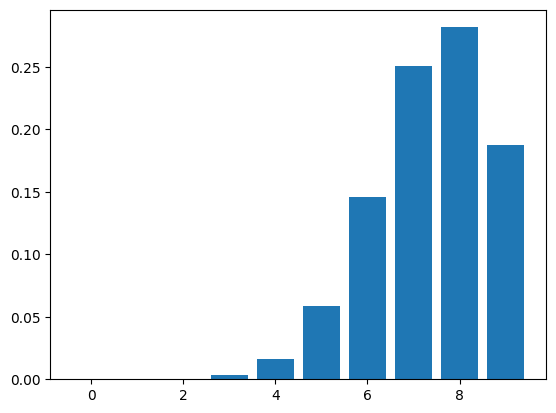

In [46]:
n = 10
p = 0.75

x = np.arange(n)

plt.bar(x, bin(x, n, p))

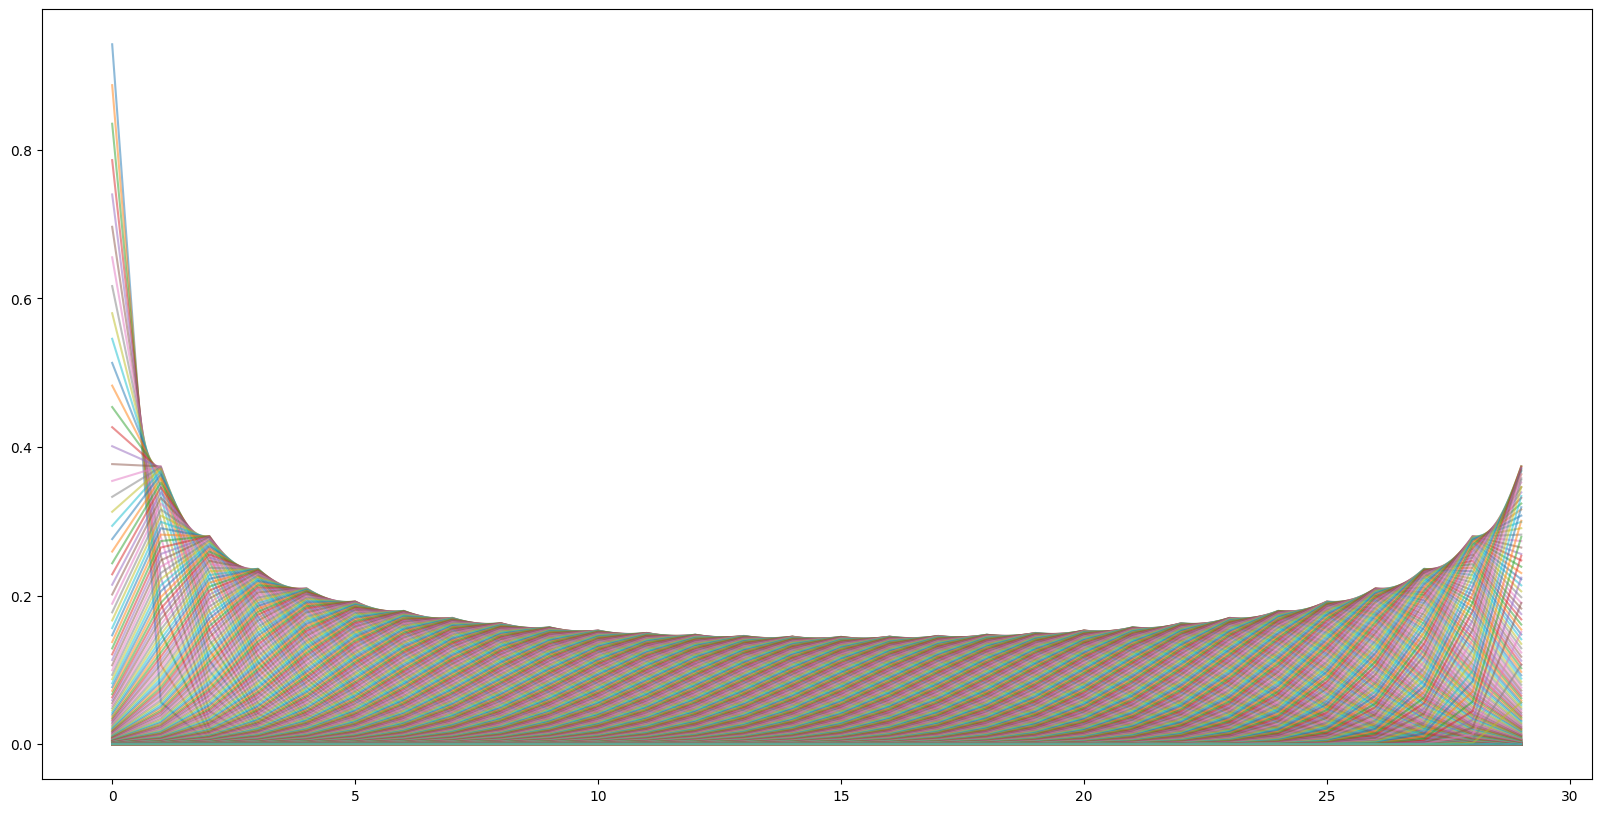

In [43]:
p_max = 500
n = 30

plt.figure(figsize=(20, 10))

for i in range(p_max):
    plt.plot(bin(np.arange(n), n, (i+1)/p_max), alpha=0.5)

<BarContainer object of 20 artists>

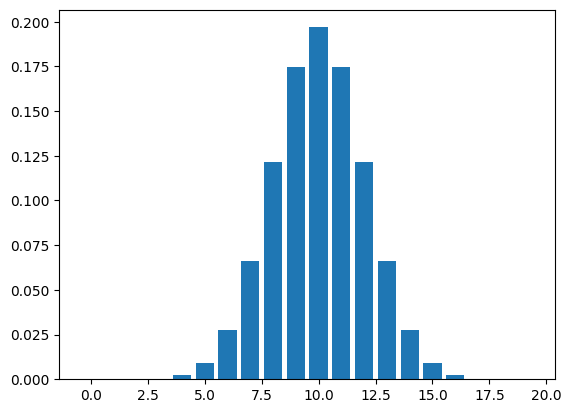

In [59]:
n = 50
M = 20
N = 100

x = np.arange(max(0, n-N+M), min(n, M))

plt.bar(x, hypgeo(x, n, M, N))

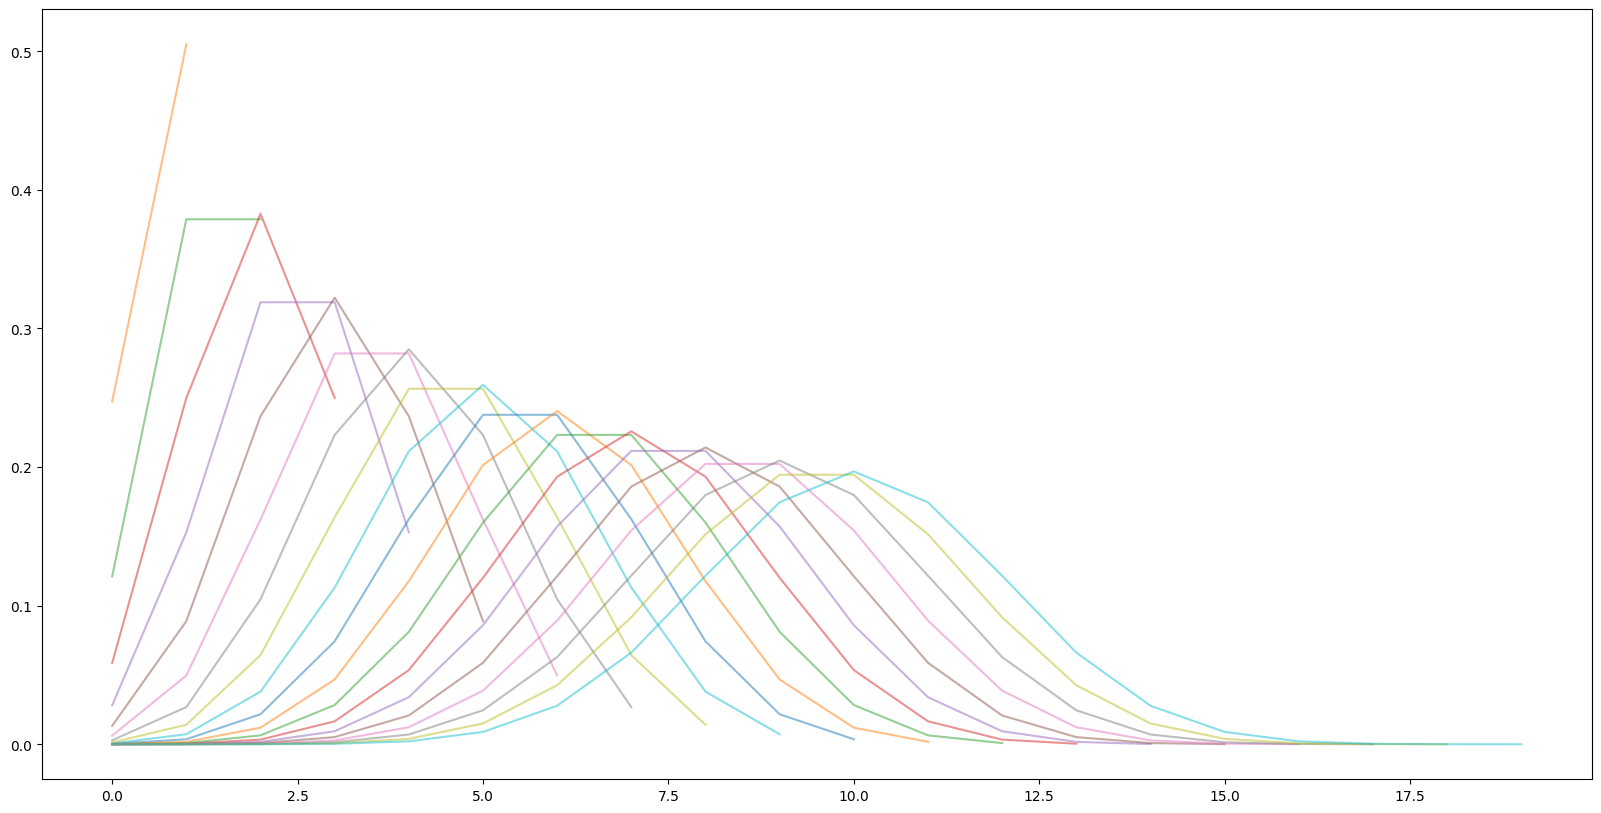

In [68]:
n = 50
N = 100
M = 20

plt.figure(figsize=(20, 10))


for Mi in range(1, M+1):
    x = np.arange(max(0, n-N+Mi), min(n, Mi))

    plt.plot(hypgeo(x, n, Mi, N), alpha=0.5)

<BarContainer object of 13 artists>

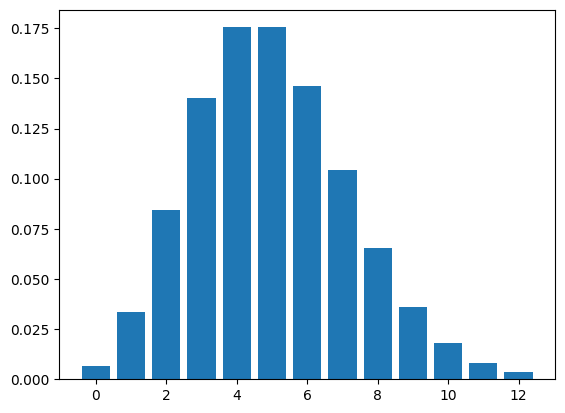

In [112]:
mu = 5

x = np.arange(0, 13, dtype=np.int64)

plt.bar(x, poisson(x, mu))

In [128]:
from math import floor

def base_b_expansion(n, b):
    q = n
    expansion = []
    while q != 0:
        expansion.append(q % b)
        q = q // b
    
    return expansion[::-1]

def add_bits(a, b, decimal=True):
    if decimal:
        a_2 = base_b_expansion(a, 2)[::-1]
        b_2 = base_b_expansion(b, 2)[::-1]
    else:
        a_2 = a
        b_2 = b

    if len(a_2) < len(b_2):
        diff = len(b_2) - len(a_2)
        a_2 = a_2 + [0]*diff
    if len(a_2) > len(b_2):
        diff = len(a_2) - len(b_2)
        b_2 = b_2 + [0]*diff
    
    n = len(a_2)
    c = 0
    added = []

    for j in range(0, n):
        d = floor((a_2[j] + b_2[j] + c) / 2)
        added.append(a_2[j] + b_2[j] + c - 2*d)
        c = d
    
    added.append(c)
    return added[::-1], sum(x*2**i for i, x in enumerate(added))

def mult_bits(a, b, decimal=True):
    if decimal:
        a_2 = base_b_expansion(a, 2)[::-1]
        b_2 = base_b_expansion(b, 2)[::-1]
    else:
        a_2 = a
        b_2 = b

    if len(a_2) < len(b_2):
        diff = len(b_2) - len(a_2)
        a_2 = a_2 + [0]*diff
    if len(a_2) > len(b_2):
        diff = len(a_2) - len(b_2)
        b_2 = b_2 + [0]*diff
    
    n = len(b_2)
    c = []

    for j in range(0, n):
        if b_2[j] == 1: 
            c.append([0]*j + a_2)
        else:
            c.append([0])
    
    p = [0]*n
    for j in range(0, n):
        p, _ = add_bits(p[::-1], c[j], decimal=False)

    return sum(x*2**i for i, x in enumerate(p[::-1])), c


def fast_mod_exp(b, n, m):
    n_2 = base_b_expansion(n, 2)[::-1]

    x = 1
    power = b % m
    for j in range(0, len(n_2)):
        if n_2[j] == 1:
            x = (x * power) % m
        power = (power * power) % m

    return x

b = 3
n = 644
m = 645
fast_mod_exp(b, n, m), b**n % m, b**n

(36,
 36,
 18453894755814916563522019223590918486343368246870670933958231251590222726152045690431356713434591761024182609241738019790843254887188990378906462569820105030502796081634220899900260910647442455063827574176935092333299240905800354674720747076125344429923081878537410422728587736681138430469885470022656524881)

In [180]:
mu = 28000
sigma = 5000
n = 250

sample = np.random.normal(mu, sigma, size=(100, n))

sample.shape

(100, 250)

In [181]:
sample.mean(axis=1).std(axis=0), sigma/n**.5

(320.34313656723856, 316.22776601683796)

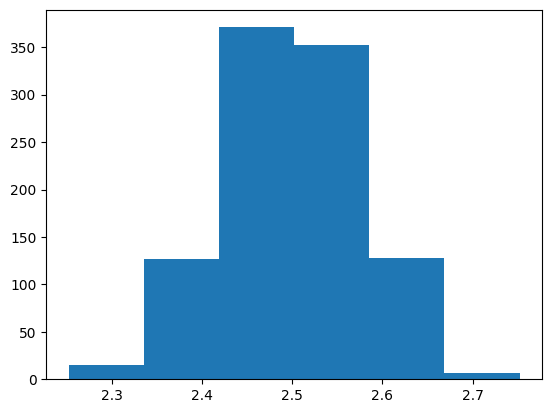

In [262]:
n = 1000
k = 500

sample = [np.random.choice(6, replace=True, size=(n)) for _ in range(k)]

plt.hist(np.mean(sample, axis=0), bins=6)
plt.show()

In [324]:
mu = 60
sigma = 5
n = 31
k = 100

sample_means = np.random.normal(mu, sigma, size=(k, n)).mean(axis=1)

left_end = sample_means - 1.96 * sigma / n**.5
right_end = sample_means + 1.96 * sigma / n**.5

((left_end < mu) & (mu < right_end)).sum() / k

0.95

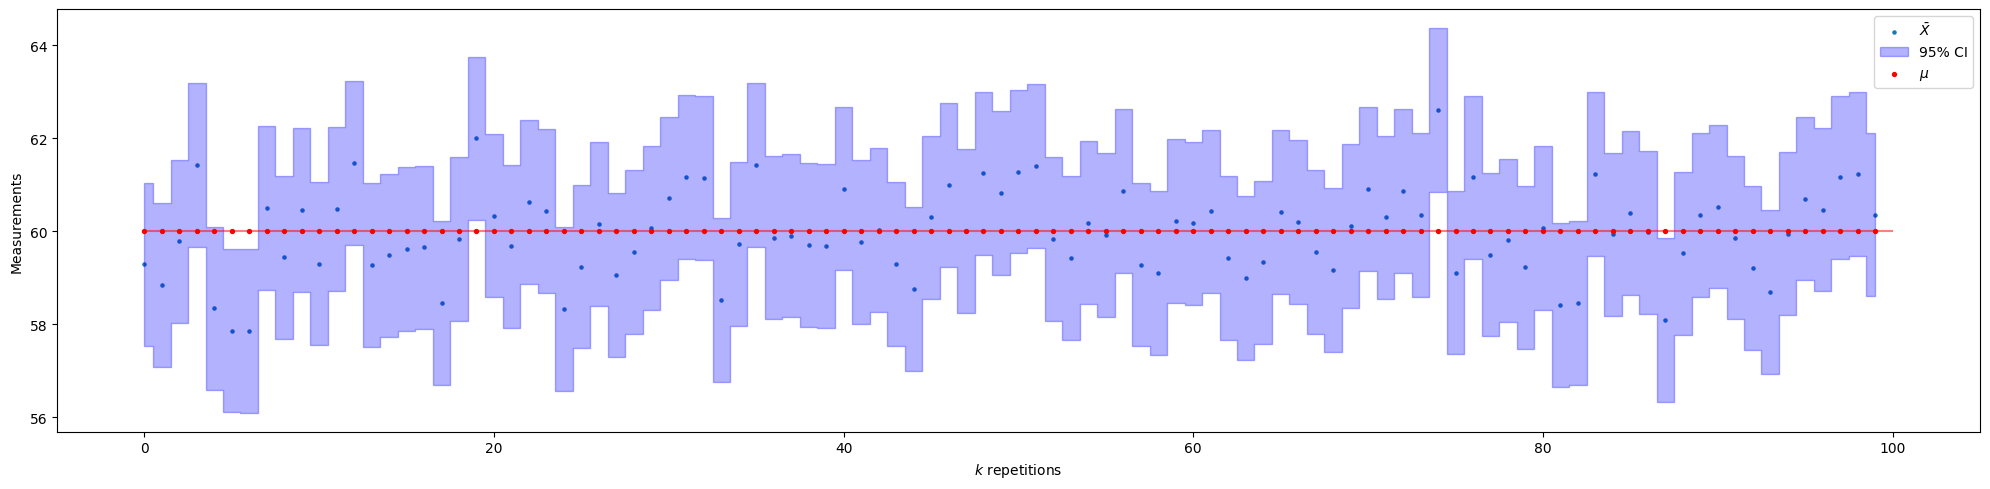

In [337]:
plt.figure(figsize=(20, 5))

plt.scatter(range(k), sample_means, s=5, label=r'$\bar{X}$')
plt.fill_between(range(k), left_end, right_end, color='b', alpha=.3, step='mid', label='95% CI')
plt.hlines(mu, 0, k, colors='red', alpha=.5)
plt.scatter(range(k), np.ones(shape=(k))*mu, s=8, c='red', label=r'$\mu$')

plt.xlabel('$k$ repetitions')
plt.ylabel('Measurements')

plt.legend()
plt.tight_layout()
plt.show()